# Exploratory Analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from olist.data import Olist

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

In [3]:
#data = Olist().get_data()
data = Olist().get_data()

In [4]:
import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [5]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

### 1 - Run an exploratory analysis with [pandas profiling](https://github.com/pandas-profiling/pandas-profiling)

In [6]:
#! pip install pandas-profiling

In [7]:
# create a new "/reports" folder 
!mkdir -p data/reports

La syntaxe de la commande n'est pas correcte.


In [8]:
list_datas = list(data.keys())
list_datas

['customers',
 'product_category_name_translation',
 'order_items',
 'order_payments',
 'orders',
 'products',
 'geolocation',
 'order_reviews',
 'sellers']

In [9]:
#import pandas_profiling
#datasets_to_profile = ['orders', 'products', 'sellers','customers', 'order_reviews','order_items']
datasets_to_profile = list_datas

In [10]:
#for d in datasets_to_profile:
#    print('exporting: '+d)
#    profile = data[d].profile_report(title='Report for '+d)
#    profile.to_file(output_file="data/reports/"+d+'.html');

In [11]:
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_cols": []
        ,"total_duplicates": []
        ,"total_null": []
        ,"null_cols": []
}

for csv in datasets_to_profile:
    dict_info["dataset"].append(csv) 
    dict_info["columns"].append([', '.join([col for col, null in data[csv].isnull().sum().items() ])])
    dict_info["total_rows"].append(data[csv].shape[0])
    dict_info["total_cols"].append(data[csv].shape[1])
    dict_info["total_duplicates"].append(len(data[csv][data[csv].duplicated()]))
    dict_info["total_null"].append(data[csv].isnull().sum().sum())
    dict_info["null_cols"].append([', '.join([col for col, null in data[csv].isnull().sum().items() if null > 0])])
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_cols,total_duplicates,total_null,null_cols
0,customers,"['customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state']",99441,5,0,0,['']
1,product_category_name_translation,"['product_category_name, product_category_name_english']",71,2,0,0,['']
2,order_items,"['order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value']",112650,7,0,0,['']
3,order_payments,"['order_id, payment_sequential, payment_type, payment_installments, payment_value']",103886,5,0,0,['']
4,orders,"['order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date']",99441,8,0,4908,"['order_approved_at, order_delivered_carrier_date, order_delivered_customer_date']"
5,products,"['product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']",32951,9,0,2448,"['product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']"
6,geolocation,"['geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state']",1000163,5,261831,0,['']
7,order_reviews,"['review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp']",99224,7,0,145903,"['review_comment_title, review_comment_message']"
8,sellers,"['seller_id, seller_zip_code_prefix, seller_city, seller_state']",3095,4,0,0,['']


In [12]:
data['geolocation'][data['geolocation'].duplicated() == True]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [13]:
# check payment types
data['order_payments']['payment_type'].value_counts()

credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64

In [14]:
# dropping nulls
#for csv in datasets_to_profile:
#    data[csv].dropna(inplace=True)

In [15]:
data['products']['product_category_name'].isnull().value_counts()

False    32341
True       610
Name: product_category_name, dtype: int64

In [16]:
data['products']['product_category_name'].fillna("unknown", inplace=True)
data['products']['product_category_name'].isnull().value_counts()

False    32951
Name: product_category_name, dtype: int64

In [17]:
# add unknown to matching table
unknown_append = {'product_category_name': 'unknown', 'product_category_name_english':'unknown'}
data['product_category_name_translation'] = data['product_category_name_translation']\
                                            .append(unknown_append, ignore_index=True)

data['product_category_name_translation']

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [18]:
# dropping duplicates
for csv in datasets_to_profile:
    data[csv].drop(data[csv][data[csv].duplicated()].index, axis=0, inplace=True)

In [19]:
# recheck :
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_cols": []
        ,"total_duplicates": []
        ,"total_null": []
        ,"null_cols": []
}

for csv in datasets_to_profile:
    dict_info["dataset"].append(csv) 
    dict_info["columns"].append([', '.join([col for col, null in data[csv].isnull().sum().items() ])])
    dict_info["total_rows"].append(data[csv].shape[0])
    dict_info["total_cols"].append(data[csv].shape[1])
    dict_info["total_duplicates"].append(len(data[csv][data[csv].duplicated()]))
    dict_info["total_null"].append(data[csv].isnull().sum().sum())
    dict_info["null_cols"].append([', '.join([col for col, null in data[csv].isnull().sum().items() if null > 0])])
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_cols,total_duplicates,total_null,null_cols
0,customers,"['customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state']",99441,5,0,0,['']
1,product_category_name_translation,"['product_category_name, product_category_name_english']",72,2,0,0,['']
2,order_items,"['order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value']",112650,7,0,0,['']
3,order_payments,"['order_id, payment_sequential, payment_type, payment_installments, payment_value']",103886,5,0,0,['']
4,orders,"['order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date']",99441,8,0,4908,"['order_approved_at, order_delivered_carrier_date, order_delivered_customer_date']"
5,products,"['product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']",32951,9,0,1838,"['product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']"
6,geolocation,"['geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state']",738332,5,0,0,['']
7,order_reviews,"['review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp']",99224,7,0,145903,"['review_comment_title, review_comment_message']"
8,sellers,"['seller_id, seller_zip_code_prefix, seller_city, seller_state']",3095,4,0,0,['']


### 2 - Creating an order matching table

Looking at our schema, it would be best to create a central `matching_table` that will join the most important foreign keys together, for later use

❓Create the `matching_table`, a DataFrame with the following columns (below).  
Use outer joins to make sure you don't lose any information at this stage.

In [20]:
columns_matching_table = [
    "order_id",
    "review_id",
    "customer_id",
    "product_id",
    "seller_id",
]

In [21]:
#### Select only the columns of interest in the various dataframes of interest, before proceeding to any merge
orders = data['orders'][['customer_id', 'order_id']]
reviews = data['order_reviews'][['order_id', 'review_id', 'review_score', 'review_comment_message']]
items = data['order_items'][['order_id', 'product_id','seller_id', 'price']]

customers = data['customers'][['customer_id', 'customer_unique_id']]
products = data['products']
product_names = data['product_category_name_translation']

In [22]:
# Inspect the cardinality of each DataFrame using pd.DataFrame.shape and pd.Series.nunique()
print('orders:', orders.shape, orders.customer_id.nunique(), 'unique customer_ids, and', orders.order_id.nunique(), 'unique order_ids')
print('review: ', reviews.shape, reviews.order_id.nunique(), 'unique order_ids and', reviews.review_id.nunique(), 'unique reviews' )
print('items: ', items.shape, items.order_id.nunique(), 'unique order_ids,', items.product_id.nunique(), 
      'unique product_ids, and', items.seller_id.nunique(), 'unique seller_ids')

orders: (99441, 2) 99441 unique customer_ids, and 99441 unique order_ids
review:  (99224, 4) 98673 unique order_ids and 98410 unique reviews
items:  (112650, 4) 98666 unique order_ids, 32951 unique product_ids, and 3095 unique seller_ids


### Product categories translation merge

In [23]:
data['order_items']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [24]:
# check product categories
data['product_category_name_translation']

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [25]:
# merge into general categories if possible
data['product_category_name_translation']['product_category_name_english'].sort_values(ascending=True).tolist()

['agro_industry_and_commerce',
 'air_conditioning',
 'art',
 'arts_and_craftmanship',
 'audio',
 'auto',
 'baby',
 'bed_bath_table',
 'books_general_interest',
 'books_imported',
 'books_technical',
 'cds_dvds_musicals',
 'christmas_supplies',
 'cine_photo',
 'computers',
 'computers_accessories',
 'consoles_games',
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'cool_stuff',
 'costruction_tools_garden',
 'costruction_tools_tools',
 'diapers_and_hygiene',
 'drinks',
 'dvds_blu_ray',
 'electronics',
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach',
 'fixed_telephony',
 'flowers',
 'food',
 'food_drink',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'garden_tools',
 'health_beauty',
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confo

In [26]:
# initially listed as a reminder to have exhaustive lists, not used
other = [
 'auto',
 'unknown'
 ]

In [27]:
books_stationery =[
 'books_general_interest',
 'books_imported',
 'books_technical',
 'stationery'
]

electronics = [
 'electronics',
 'computers',
 'computers_accessories',
 'dvds_blu_ray',
 'fixed_telephony',
 'telephony',
 'small_appliances',
 'small_appliances_home_oven_and_coffee',
 'tablets_printing_image'
]

construction = [
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'costruction_tools_tools',
 'home_construction'
]

garden = [
 'costruction_tools_garden',
 'garden_tools'
]


fashion = [
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach'
]


furniture = [
 'bed_bath_table',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'office_furniture',
 'kitchen_dining_laundry_garden_furniture',
 'la_cuisine'
]

health_beauty = [
 'health_beauty',
 'perfumery',
 'baby',
 'diapers_and_hygiene'
]

home = [
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confort',
 'housewares',
 'flowers',
 'christmas_supplies',
 'party_supplies'
]


toys_gifts = [
 'toys',
 'watches_gifts',
 'cool_stuff'
]

sports_leisure = [
 'sports_leisure',
 'cine_photo',
 'musical_instruments',
 'art',
 'arts_and_craftmanship',
 'cds_dvds_musicals',
 'music',
 'consoles_games',
 'audio'
]

misc = [
 'agro_industry_and_commerce',
 'air_conditioning',
 'industry_commerce_and_business',
 'luggage_accessories',
 'market_place',
 'pet_shop',
 'security_and_services',
 'signaling_and_security',
 'drinks',
 'food',
 'food_drink'
 ]



In [28]:
product_names["product_global_category"] = product_names["product_category_name_english"]

In [29]:
product_names['product_global_category'] = product_names['product_global_category'].replace(books_stationery, 'books_stationery')
product_names['product_global_category'] = product_names['product_global_category'].replace(electronics, 'electronics')
product_names['product_global_category'] = product_names['product_global_category'].replace(construction, 'construction')
product_names['product_global_category'] = product_names['product_global_category'].replace(garden, 'garden')
product_names['product_global_category'] = product_names['product_global_category'].replace(fashion, 'fashion')
product_names['product_global_category'] = product_names['product_global_category'].replace(furniture, 'furniture')
product_names['product_global_category'] = product_names['product_global_category'].replace(health_beauty, 'health_beauty')
product_names['product_global_category'] = product_names['product_global_category'].replace(home, 'home')
product_names['product_global_category'] = product_names['product_global_category'].replace(toys_gifts, 'toys_gifts')
product_names['product_global_category'] = product_names['product_global_category'].replace(sports_leisure, 'sports_leisure')
product_names['product_global_category'] = product_names['product_global_category'].replace(misc, 'misc')

In [30]:
product_names['product_global_category'].nunique()

13

In [31]:
product_names['product_global_category'].value_counts()

misc                11
electronics          9
sports_leisure       9
furniture            8
home                 8
fashion              7
construction         5
health_beauty        4
books_stationery     4
toys_gifts           3
garden               2
auto                 1
unknown              1
Name: product_global_category, dtype: int64

In [32]:
# merge

In [33]:
data['products']['product_category_name'].value_counts()

cama_mesa_banho                                   3029
esporte_lazer                                     2867
moveis_decoracao                                  2657
beleza_saude                                      2444
utilidades_domesticas                             2335
automotivo                                        1900
informatica_acessorios                            1639
brinquedos                                        1411
relogios_presentes                                1329
telefonia                                         1134
bebes                                              919
perfumaria                                         868
fashion_bolsas_e_acessorios                        849
papelaria                                          849
cool_stuff                                         789
ferramentas_jardim                                 753
pet_shop                                           719
unknown                                            610
eletronico

In [34]:
products = products.merge(product_names, on='product_category_name', how='left')

In [35]:
products = products.reindex(['product_id', 'product_category_name',  'product_category_name_english', 'product_global_category', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'], axis=1)

In [36]:
#products['product_category_name_english'].value_counts()
#products['product_category_name_english'].value_counts().sort_index(ascending=True)

In [37]:
products.head()

,product_id,product_category_name,product_category_name_english,product_global_category,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,health_beauty,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,sports_leisure,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,health_beauty,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,home,37.0,402.0,4.0,625.0,20.0,17.0,13.0


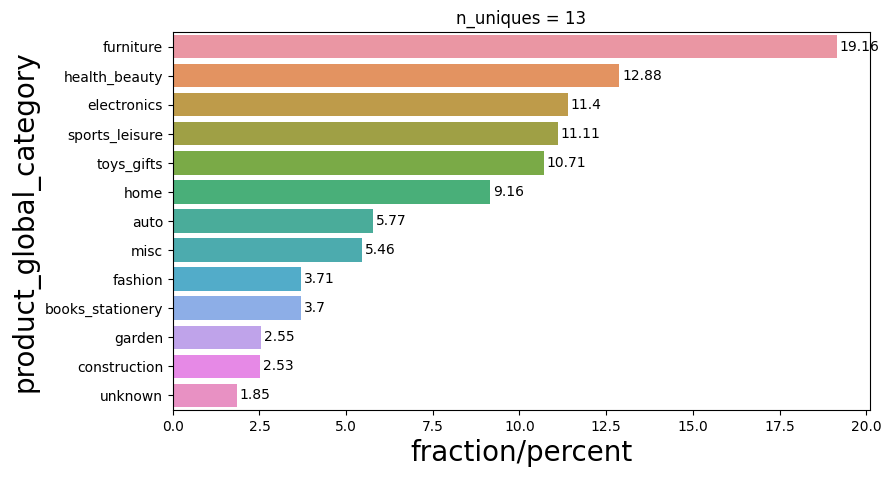

In [38]:
UVA.category(products, ['product_global_category'], 9, 5)

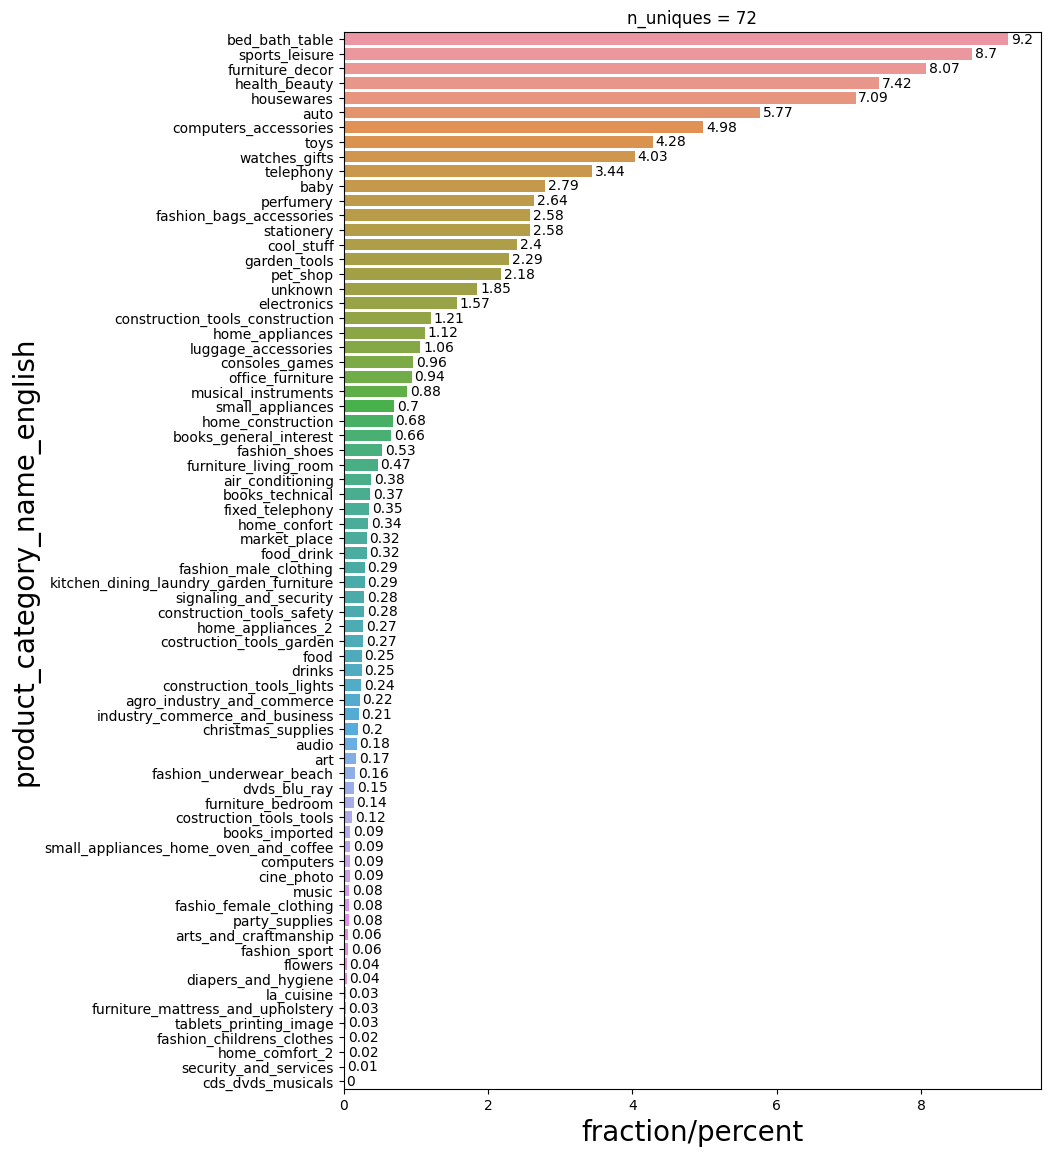

In [39]:
UVA.category(products, ['product_category_name_english'], 9, 14)

### Orders merge

In [40]:
# Carefully merge DataFrames
matching_table = orders.merge(reviews, on='order_id', how='left').merge(items, on='order_id', how='left')
matching_table

,customer_id,order_id,review_id,review_score,review_comment_message,product_id,seller_id,price
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,a54f0611adc9ed256b57ede6b6eb5114,4.0,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,8d5266042046a06655c8db133d120ba5,4.0,Muito bom o produto.,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,359d03e676b3c069f62cadba8dd3f6e8,5.0,O produto foi exatamente o que eu esperava e estava descrito no site e chegou bem antes da data prevista.,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,e50934924e227544ba8246aeb3770dd4,5.0,NaN,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90
...,...,...,...,...,...,...,...,...
114087,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,29bb71b2760d0f876dfa178a76bc4734,4.0,So uma peça que veio rachado mas tudo bem rs,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,174.90
114088,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,371579771219f6db2d830d50805977bb,5.0,Foi entregue antes do prazo.,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,205.99
114089,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,8ab6855b9fe9b812cd03a480a25058a1,2.0,Foi entregue somente 1. Quero saber do outro produto.,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99
114090,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,8ab6855b9fe9b812cd03a480a25058a1,2.0,Foi entregue somente 1. Quero saber do outro produto.,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99


In [41]:
matching_table = orders\
        .merge(customers, on='customer_id', how='outer')\
        .merge(reviews, on="order_id", how="outer")\
        .merge(items, on="order_id", how="outer")
matching_table

,customer_id,order_id,customer_unique_id,review_id,review_score,review_comment_message,product_id,seller_id,price
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,a54f0611adc9ed256b57ede6b6eb5114,4.0,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,8d5266042046a06655c8db133d120ba5,4.0,Muito bom o produto.,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,359d03e676b3c069f62cadba8dd3f6e8,5.0,O produto foi exatamente o que eu esperava e estava descrito no site e chegou bem antes da data prevista.,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,e50934924e227544ba8246aeb3770dd4,5.0,NaN,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90
...,...,...,...,...,...,...,...,...,...
114087,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,29bb71b2760d0f876dfa178a76bc4734,4.0,So uma peça que veio rachado mas tudo bem rs,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,174.90
114088,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,371579771219f6db2d830d50805977bb,5.0,Foi entregue antes do prazo.,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,205.99
114089,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,2.0,Foi entregue somente 1. Quero saber do outro produto.,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99
114090,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,2.0,Foi entregue somente 1. Quero saber do outro produto.,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99


In [42]:
# test get matching table
matching_table_import = Olist().get_matching_table()
matching_table_import

,customer_id,order_id,customer_unique_id,review_id,product_id,seller_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,a54f0611adc9ed256b57ede6b6eb5114,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,8d5266042046a06655c8db133d120ba5,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,e73b67b67587f7644d5bd1a52deb1b01,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,359d03e676b3c069f62cadba8dd3f6e8,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,e50934924e227544ba8246aeb3770dd4,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8
...,...,...,...,...,...,...
114087,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,29bb71b2760d0f876dfa178a76bc4734,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554
114088,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,371579771219f6db2d830d50805977bb,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48
114089,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48
114090,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48


In [43]:
# Inspect the cardinality and `nunique` of the final DataFrame. It should match (114100, 5)
print(matching_table.shape)
print('unique values: ')
print(matching_table.nunique())

(114092, 9)
unique values: 
customer_id               99441
order_id                  99441
customer_unique_id        96096
review_id                 98410
review_score                  5
review_comment_message    36159
product_id                32951
seller_id                  3095
price                      5968
dtype: int64


In [44]:
# check n# orders per customer

In [45]:
#orders = data['orders'][['customer_id', 'order_id']]
#customers = data['customers'][['customer_id', 'customer_unique_id']]

In [46]:
match_orders = orders.merge(customers, on='customer_id', how='left')

In [47]:
match_orders

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6
...,...,...,...
99436,39bd1228ee8140590ac3aca26f2dfe00,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a
99437,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660
99438,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30
99439,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c


In [48]:
orders_count = match_orders \
                .groupby('customer_unique_id')['order_id'] \
                .nunique().reset_index(name='orders_count')

In [49]:
orders_count['count_category'] = np.where(orders_count['orders_count'] == 1, '1', '2+')

In [50]:
orders_count.sort_values(by='orders_count', ascending=False)

,customer_unique_id,orders_count,count_category
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17,2+
23472,3e43e6105506432c953e165fb2acf44c,9,2+
37797,6469f99c1f9dfae7733b25662e7f1782,7,2+
76082,ca77025e7201e3b30c44b472ff346268,7,2+
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7,2+
...,...,...,...
32508,5657dfebff5868c4dc7e8355fea865c4,1,1
32507,5657596addb4d7b07b32cd330614bdf8,1,1
32506,5656eb169546146caeab56c3ffc3d268,1,1
32505,5656a8fabc8629ff96b2bc14f8c09a27,1,1


In [51]:
orders_info = pd.concat([orders_count['orders_count'].value_counts(normalize=True),
                        orders_count['orders_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count customers'))
orders_info.index.name = 'orders per customer'
orders_info

,percent,count customers
orders per customer,,
1,0.968812,93099
2,0.028565,2745
3,0.002112,203
4,0.000312,30
5,0.000083,8
6,0.000062,6
7,0.000031,3
9,0.000010,1
17,0.000010,1


In [52]:
orders_info_cum = pd.concat([orders_count['count_category'].value_counts(normalize=True),
                        orders_count['count_category'].value_counts()], 
                        axis=1,
                        keys=('perc','count'))
orders_info_cum.index.name = 'orders per customer'


=> ~3.12 % of the total of customers (2997 total) has made more than 1 order.

In [53]:
## selecting / merging data for clustering


In [54]:
match_orders = match_orders.merge(orders_count, on='customer_unique_id', how='left')

In [55]:
match_orders

,customer_id,order_id,customer_unique_id,orders_count,count_category
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2,2+
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,1,1
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,1,1
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,1,1
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,1,1
...,...,...,...,...,...
99436,39bd1228ee8140590ac3aca26f2dfe00,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,1,1
99437,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,1,1
99438,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,1,1
99439,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,1,1


In [56]:
## picking orders from customers_unique_id having made more than 2 orders 
match_orders_2p = match_orders[['customer_id','order_id', 'customer_unique_id']].loc[match_orders['orders_count'] > 1]
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99307,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99344,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99347,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99419,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [57]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99307,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99344,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99347,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99419,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [58]:
##  adding orders categories and reviews info

In [59]:
reviews

,order_id,review_id,review_score,review_comment_message
0,73fc7af87114b39712e6da79b0a377eb,7bc2406110b926393aa56f80a40eba40,4,NaN
1,a548910a1c6147796b98fdf73dbeba33,80e641a11e56f04c1ad469d5645fdfde,5,NaN
2,f9e4b658b201a9f2ecdecbb34bed034b,228ce5500dc1d8e020d8d1322874b6f0,5,NaN
3,658677c97b385a9be170737859d3511b,e64fb393e7b32834bb789ff8bb30750e,5,Recebi bem antes do prazo estipulado.
4,8e6bfb81e283fa7e4f11123a3fb894f1,f7c4243c7fe1938f181bec41a392bdeb,5,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa
...,...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,574ed12dd733e5fa530cfd4bbf39d7c9,5,NaN
99220,22ec9f0669f784db00fa86d035cf8602,f3897127253a9592a73be9bdfdf4ed7a,5,NaN
99221,55d4004744368f5571d1f590031933e4,b3de70c89b1510c4cd3d0649fd302472,5,"Excelente mochila, entrega super rápida. Super recomendo essa loja!"
99222,7725825d039fc1f0ceb7635e3f7d9206,1adeb9d84d72fe4e337617733eb85149,4,NaN


In [60]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99307,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99344,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99347,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99419,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [61]:
m_df = match_orders_2p \
    .merge(items[['order_id', 'product_id', 'price']], on='order_id', how='left') \
    .merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left') \
    .merge(reviews, on='order_id', how='left')

In [62]:
m_df

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name_english,review_id,review_score,review_comment_message
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,29.99,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente."
1,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f,009c09f439988bc06a93d6b8186dce73,132.40,perfumery,5a8608437f4b52bec5cd143f37258b5e,5.0,Obrigado pela atenção. Lojas lannister perfeito em tudo.
2,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5,638bbb2a5e4f360b71f332ddfebfd672,1299.00,construction_tools_construction,NaN,NaN,NaN
3,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259,c50ca07e9e4db9ea5011f06802c0aea0,14.49,health_beauty,5853e27c64b89e222c5e4edf78bec3d4,1.0,NaN
4,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514,ba4bfbf74dbe7ab37e263b9326da0523,36.90,sports_leisure,bcab37e37778893d858b3d159849a56d,4.0,NaN
...,...,...,...,...,...,...,...,...,...
8240,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b,f5e585e188891ed071253bacfad60820,194.80,computers_accessories,d3006c9fd3bef31b68bd680fe4098202,5.0,Adquiri 4 cartuchos 41 Canon e recebi somente 2 até o momento.
8241,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1,d220fdef3dfe133c5a725ee59ce99595,349.90,auto,dd378bada585d0bd633bf39fc9574548,5.0,NaN
8242,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf,NaN,NaN,NaN,047fd109ced39e02296f6aeb74f6a6f1,4.0,NaN
8243,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc,9e10ae46a3021a02f1692448ef9fa1db,37.90,health_beauty,47697b20bcd3995f870e284fad248ac8,4.0,NaN


In [63]:
# more rows => more items/products total than orders total (i.e. orders with multiple items)
# check out orders with multiple items to be sure it will be usable / absence of duplicates (in price for ex)

In [64]:
product_count = m_df \
                .groupby('order_id')['product_id'] \
                .nunique().reset_index(name='prod_count')
product_count.sort_values(by='prod_count', ascending=False)

,order_id,prod_count
5686,e43f88863d1cc9cff18d753d439d42e8,6
2248,5a3b1c29a49756e75f1ef513383c0c12,6
324,0c57cbfd927d9e62af8beee6d48920b7,5
5075,cc2999bc678cab0949b90c4759d7a284,4
3116,7e3fefb35b0b1d765a343618ca5d454c,4
...,...,...
4579,b90cc9e10252911c2092a1e49794aa13,0
5363,d69fcef5a5fe3a3db60ea65c6ee499cc,0
3038,7a9d4c7f9b068337875b95465330f2fc,0
6148,f81e71dd7c044a9ee7c1d6e37d68d64f,0


In [65]:
product_info = pd.concat([product_count['prod_count'].value_counts(normalize=True),
                        product_count['prod_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count orders'))
product_info.index.name = 'products per order'
product_info

,percent,count orders
products per order,,
1,0.925891,5872
2,0.047304,300
0,0.016872,107
3,0.008199,52
4,0.001261,8
6,0.000315,2
5,0.000158,1


In [66]:
# checking order 5a3b1c29a49756e75f1ef513383c0c12

#m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

# handles duplicates from matching_table (reviews...)
m_df[['product_id', 'price', 'product_category_name_english']]\
.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']\
.drop_duplicates()

,product_id,price,product_category_name_english
1415,99444c1e11fc38755dae86f5c67d3d1a,49.99,bed_bath_table
1417,17d8b8e9c21ec0fc5b33724e32fe422e,58.90,bed_bath_table
1419,399f54c06661d06ca45c6e24ed238e0e,61.90,bed_bath_table
1421,6a0713a63e990052795623e76cc2995e,72.90,bed_bath_table
1427,d25bbb182b51d1594fe3b54a27ae143e,69.90,bed_bath_table
1429,e95fb3a80ca294f39de925b6428f3a32,78.90,bed_bath_table


In [67]:
# check products
check_prod = m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_category_name_english,product_global_category,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
5347,d25bbb182b51d1594fe3b54a27ae143e,cama_mesa_banho,bed_bath_table,furniture,34.0,308.0,1.0,1900.0,58.0,15.0,46.0
14912,6a0713a63e990052795623e76cc2995e,cama_mesa_banho,bed_bath_table,furniture,31.0,151.0,1.0,900.0,40.0,4.0,30.0
20180,17d8b8e9c21ec0fc5b33724e32fe422e,cama_mesa_banho,bed_bath_table,furniture,26.0,212.0,2.0,1000.0,30.0,4.0,40.0
25905,e95fb3a80ca294f39de925b6428f3a32,cama_mesa_banho,bed_bath_table,furniture,29.0,263.0,1.0,1300.0,33.0,9.0,38.0
29768,99444c1e11fc38755dae86f5c67d3d1a,cama_mesa_banho,bed_bath_table,furniture,40.0,162.0,1.0,900.0,33.0,9.0,38.0
30087,399f54c06661d06ca45c6e24ed238e0e,cama_mesa_banho,bed_bath_table,furniture,34.0,216.0,2.0,1100.0,33.0,9.0,38.0


In [68]:
items.loc[items['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

,order_id,product_id,seller_id,price
39679,5a3b1c29a49756e75f1ef513383c0c12,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,49.99
39680,5a3b1c29a49756e75f1ef513383c0c12,17d8b8e9c21ec0fc5b33724e32fe422e,d2374cbcbb3ca4ab1086534108cc3ab7,58.90
39681,5a3b1c29a49756e75f1ef513383c0c12,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,61.90
39682,5a3b1c29a49756e75f1ef513383c0c12,6a0713a63e990052795623e76cc2995e,d2374cbcbb3ca4ab1086534108cc3ab7,72.90
39683,5a3b1c29a49756e75f1ef513383c0c12,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,49.99
39684,5a3b1c29a49756e75f1ef513383c0c12,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,61.90
39685,5a3b1c29a49756e75f1ef513383c0c12,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,69.90
39686,5a3b1c29a49756e75f1ef513383c0c12,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,78.90
39687,5a3b1c29a49756e75f1ef513383c0c12,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,78.90
39688,5a3b1c29a49756e75f1ef513383c0c12,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,69.90


In [69]:
# checking order e43f88863d1cc9cff18d753d439d42e8
m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name_english,review_id,review_score,review_comment_message
4291,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,9036be77e0a74cca6eeef0740649b97b,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN
4292,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,238314b88e4b8ffa496db6b1a201d897,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN
4293,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,28447390cfd2a411fcb8c008b6163da2,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN
4294,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,2e0b9273624db778d82fd3b18becec24,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN
4295,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,8fa5bb1e4de7a63ee554487c2f2ee076,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN
4296,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,b65214d387c754bb0f858a4a5a0f41ad,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN


In [70]:
# check products
check_prod = m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_category_name_english,product_global_category,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1102,28447390cfd2a411fcb8c008b6163da2,brinquedos,toys,toys_gifts,57.0,696.0,4.0,405.0,21.0,7.0,16.0
14154,8fa5bb1e4de7a63ee554487c2f2ee076,brinquedos,toys,toys_gifts,58.0,696.0,4.0,325.0,21.0,7.0,16.0
19331,2e0b9273624db778d82fd3b18becec24,brinquedos,toys,toys_gifts,57.0,707.0,4.0,345.0,19.0,16.0,18.0
23282,9036be77e0a74cca6eeef0740649b97b,brinquedos,toys,toys_gifts,57.0,697.0,3.0,405.0,21.0,7.0,15.0
24483,b65214d387c754bb0f858a4a5a0f41ad,brinquedos,toys,toys_gifts,57.0,696.0,4.0,325.0,21.0,7.0,16.0
31683,238314b88e4b8ffa496db6b1a201d897,brinquedos,toys,toys_gifts,56.0,696.0,4.0,300.0,21.0,7.0,16.0


In [71]:
items.loc[items['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,order_id,product_id,seller_id,price
100670,e43f88863d1cc9cff18d753d439d42e8,9036be77e0a74cca6eeef0740649b97b,de23c3b98a88888289c6f5cc1209054a,69.99
100671,e43f88863d1cc9cff18d753d439d42e8,238314b88e4b8ffa496db6b1a201d897,de23c3b98a88888289c6f5cc1209054a,69.99
100672,e43f88863d1cc9cff18d753d439d42e8,28447390cfd2a411fcb8c008b6163da2,de23c3b98a88888289c6f5cc1209054a,69.99
100673,e43f88863d1cc9cff18d753d439d42e8,2e0b9273624db778d82fd3b18becec24,de23c3b98a88888289c6f5cc1209054a,69.99
100674,e43f88863d1cc9cff18d753d439d42e8,8fa5bb1e4de7a63ee554487c2f2ee076,de23c3b98a88888289c6f5cc1209054a,69.99
100675,e43f88863d1cc9cff18d753d439d42e8,b65214d387c754bb0f858a4a5a0f41ad,de23c3b98a88888289c6f5cc1209054a,69.99


In [72]:
# => may have to handle the "duplicate" prices not matching reality (price of the whole order for singular products)

In [73]:
## conseils vidéo introductive projet : https://www.youtube.com/watch?v=BI4UFzIYBG8
# méthodologie, itérations.
# commencer par features simples, ex :
#   RFM :
#    - Récence : nb de jours depuis dernier achat,
#    - Fréquence : nb de fois que la personne a acheté,
#    - Montant :montant total des achats
# 
# => lier tables, agréger features (groupby, agg)
# 
# => faire bivariée sur le dataset créé
#
# une fois dataset obtenu, débuter modélisation
# - bien analyser données
#   - faire PCA
#   - projeter individus
#   - faire cercle de correlations
#
#   (Score de silhouette)
#
# - modélisation
#   - CAAH
#   - KMEANS (boucler sur plusieurs clusters, radar chart)
#   - dbscan
#   - déterminer nb clusters
#   - regarder/analyser clusters : bien comprendre les distinctions
#
# - repasser sur données
#   - ajouter quelques features sur dataset : reviewscore moyen, différence date d'achat/livraison, retard/delta livraison
#   - 
#   - 
#
# - débuter travail maintenance
#   - étape importante
#   - dder mentor


# Dataset RFM

## Préparation

In [74]:
data['orders']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [75]:
ord_time = data['orders'][['order_id','customer_id', 'order_purchase_timestamp']]
ord_time = ord_time.merge(customers, on='customer_id', how='left')\
[['customer_unique_id', 'order_id', 'order_purchase_timestamp']]
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39
...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05
99437,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58
99438,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43
99439,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27


In [76]:
ord_time['order_purchase_timestamp'] = pd.to_datetime(ord_time['order_purchase_timestamp']).dt.date

In [77]:
ord_time['order_purchase_timestamp'].isnull().values.any()

False

In [78]:
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13
...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09
99437,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06
99438,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27
99439,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08


In [79]:
orders_price = items.groupby(['order_id']).agg('sum')
orders_price.head()

,price
order_id,
00010242fe8c5a6d1ba2dd792cb16214,58.90
00018f77f2f0320c557190d7a144bdd3,239.90
000229ec398224ef6ca0657da4fc703e,199.00
00024acbcdf0a6daa1e931b038114c75,12.99
00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [80]:
# rename / reorganize dataset
ord_df = ord_time.merge(orders_price, on='order_id', how='outer')
ord_df.rename({'price':'total_revenue', 'order_purchase_timestamp': 'purchase_date'}, axis='columns', inplace=True)
ord_df = ord_df[['order_id', 'customer_unique_id', 'total_revenue', 'purchase_date']]
ord_df

,order_id,customer_unique_id,total_revenue,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,2018-02-13
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,2017-03-09
99437,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,2018-02-06
99438,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,2017-08-27
99439,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,2018-01-08


In [81]:
# Recency

=> To define 'Recency' we have to take into account the limit of the current dataframe, more than a min/max date, a simple analysis/display of the distribution of orders over dates would help (can cover some errors/outliers to get the general picture).

In [82]:
# check min / max dates and overall dates distribution of orders
# convert timestamp to date

In [83]:
ord_df.dtypes

order_id               object
customer_unique_id     object
total_revenue         float64
purchase_date          object
dtype: object

In [84]:
min_date = ord_df['purchase_date'].min(axis=0)
max_date = ord_df['purchase_date'].max(axis=0)
print(min_date)
print(max_date)

2016-09-04
2018-10-17


In [85]:
ord_time_dist = ord_df['purchase_date'].value_counts().sort_index()
ord_time_dist

2016-09-04       1
2016-09-05       1
2016-09-13       1
2016-09-15       1
2016-10-02       1
2016-10-03       8
2016-10-04      63
2016-10-05      47
2016-10-06      51
2016-10-07      46
2016-10-08      42
2016-10-09      26
2016-10-10      39
2016-10-22       1
2016-12-23       1
2017-01-05      32
2017-01-06       4
2017-01-07       4
2017-01-08       6
2017-01-09       5
2017-01-10       6
2017-01-11      12
2017-01-12      13
2017-01-13      12
2017-01-14      18
2017-01-15      14
2017-01-16      19
2017-01-17      32
2017-01-18      33
2017-01-19      29
2017-01-20      29
2017-01-21      24
2017-01-22      31
2017-01-23      39
2017-01-24      40
2017-01-25      63
2017-01-26      86
2017-01-27      62
2017-01-28      29
2017-01-29      35
2017-01-30      53
2017-01-31      70
2017-02-01      73
2017-02-02      69
2017-02-03      60
2017-02-04      67
2017-02-05      75
2017-02-06      85
2017-02-07     112
2017-02-08      95
2017-02-09      77
2017-02-10      66
2017-02-11  

In [86]:
#ord_time_dist.plot()

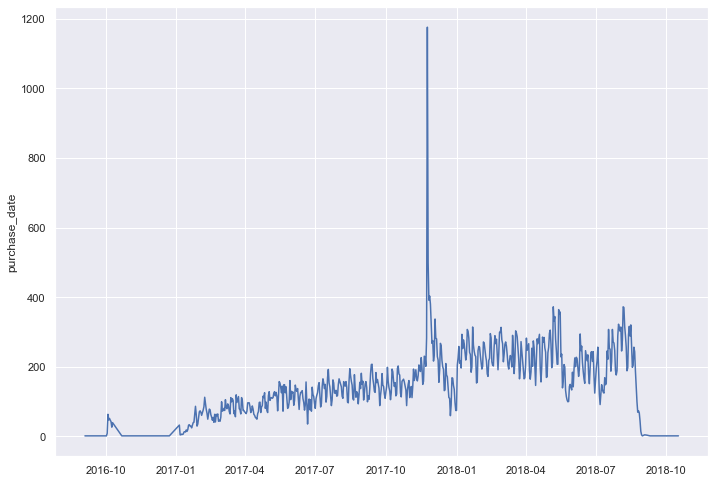

In [87]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
g = sns.lineplot(data=ord_time_dist)

In [88]:
max_date

datetime.date(2018, 10, 17)

In [89]:
ord_df

,order_id,customer_unique_id,total_revenue,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,2018-02-13
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,2017-03-09
99437,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,2018-02-06
99438,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,2017-08-27
99439,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,2018-01-08


In [90]:
# https://practicaldatascience.co.uk/data-science/how-to-assign-rfm-scores-with-quantile-based-discretization
# => Recency is a measure of the number of days since the customer last placed an order. 

# Consolidation Dataframe RFM

In [91]:
df_customers = pd.DataFrame(ord_df['customer_unique_id'].unique())
df_customers.columns = ['customer_unique_id']
df_customers.head()

,customer_unique_id
0,7c396fd4830fd04220f754e42b4e5bff
1,af07308b275d755c9edb36a90c618231
2,3a653a41f6f9fc3d2a113cf8398680e8
3,7c142cf63193a1473d2e66489a9ae977
4,72632f0f9dd73dfee390c9b22eb56dd6


In [92]:
df_recency = ord_df.groupby('customer_unique_id')['purchase_date'].max().reset_index()
df_recency.columns = ['customer_unique_id'
                      ,'recency_date'
                     ]
df_customers = df_customers.merge(df_recency, on='customer_unique_id')
df_customers['recency'] = round((pd.to_datetime('2018-10-17') - pd.to_datetime(df_customers['recency_date']))\
                                / np.timedelta64(1, 'D') ).astype(int)

In [93]:
df_customers

,customer_unique_id,recency_date,recency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,380
1,af07308b275d755c9edb36a90c618231,2018-07-24,85
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,70
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18,333
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,246
...,...,...,...
96091,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,587
96092,da62f9e57a76d978d02ab5362c509660,2018-02-06,253
96093,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,416
96094,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,282


In [94]:
### Frequency

# Order frequency is simply the number of orders each customer has placed. 

In [95]:
df_frequency = ord_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
df_frequency.columns = ['customer_unique_id','frequency']
df_customers = df_customers.merge(df_frequency, on='customer_unique_id')

In [96]:
df_customers

,customer_unique_id,recency_date,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,380,2
1,af07308b275d755c9edb36a90c618231,2018-07-24,85,1
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,70,1
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18,333,1
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,246,1
...,...,...,...,...
96091,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,587,1
96092,da62f9e57a76d978d02ab5362c509660,2018-02-06,253,1
96093,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,416,1
96094,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,282,1


In [97]:
### Monetary value

# The monetary value column is the sum() of the total_revenue column for each customer. 

In [98]:
ord_df['total_revenue'].describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: total_revenue, dtype: float64

In [99]:
ord_df['total_revenue'].isna().value_counts()

False    98666
True       775
Name: total_revenue, dtype: int64

In [100]:
# drop orders with no price listed
ord_df.dropna(subset=['total_revenue'], inplace=True)

ord_df['total_revenue'].isna().value_counts()

False    98666
Name: total_revenue, dtype: int64

In [101]:
ord_df

,order_id,customer_unique_id,total_revenue,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,2018-02-13
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,2017-03-09
99437,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,2018-02-06
99438,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,2017-08-27
99439,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,2018-01-08


In [102]:
df_customers

,customer_unique_id,recency_date,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,380,2
1,af07308b275d755c9edb36a90c618231,2018-07-24,85,1
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,70,1
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18,333,1
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,246,1
...,...,...,...,...
96091,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,587,1
96092,da62f9e57a76d978d02ab5362c509660,2018-02-06,253,1
96093,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,416,1
96094,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,282,1


In [103]:
df_monetary = ord_df.groupby('customer_unique_id')['total_revenue'].sum().reset_index()
df_monetary.columns = ['customer_unique_id','monetary']

In [104]:
df_monetary['monetary'].describe()

count    95420.000000
mean       142.440198
std        217.656355
min          0.850000
25%         47.900000
50%         89.900000
75%        155.000000
max      13440.000000
Name: monetary, dtype: float64

In [105]:
df_monetary.loc[df_monetary['monetary'] == 0]['customer_unique_id'].nunique()

0

In [106]:
# retrait des customers sans achat
df_monetary.dropna(subset=['monetary'], inplace=True)

In [107]:
mask_value = df_monetary['monetary'] == 0
df_monetary = df_monetary.loc[~mask_value]

In [108]:
df_monetary.describe()

,monetary
count,95420.000000
mean,142.440198
std,217.656355
min,0.850000
25%,47.900000
50%,89.900000
75%,155.000000
max,13440.000000


In [109]:
df_customers = df_customers.merge(df_monetary, on='customer_unique_id')

df_customers.drop(['recency_date'], axis=1, inplace=True)
df_customers

,customer_unique_id,recency,frequency,monetary
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38
1,af07308b275d755c9edb36a90c618231,85,1,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90
...,...,...,...,...
95415,6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00
95416,da62f9e57a76d978d02ab5362c509660,253,1,174.90
95417,737520a9aad80b3fbbdad19b66b37b30,416,1,205.99
95418,5097a5312c8b157bb7be58ae360ef43c,282,1,359.98


# Most-frequently bought category

In [110]:
#ord_df.head()

In [111]:
#products.head()

In [112]:
#matching_table.head()

In [113]:
custo_product = matching_table[['customer_unique_id', 'product_id']]\
    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')
custo_product.head()

,customer_unique_id,product_id,product_global_category
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,home
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,home
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,home
3,e781fdcc107d13d865fc7698711cc572,87285b34884572647811a353c7ac498a,home
4,af07308b275d755c9edb36a90c618231,595fac2a385ac33a80bd5114aec74eb8,health_beauty


In [114]:
# check custo_product nans
custo_product.isna().sum()

customer_unique_id          0
product_id                  0
product_global_category    24
dtype: int64

In [115]:
custo_product.loc[custo_product['product_global_category'].isna()]

,customer_unique_id,product_id,product_global_category
18741,24a0683609e642fe0d86e5e2c97712f5,1954739d84629e7323a4295812a3e0ec,NaN
31195,949921a7831eb8901f75baf57d1853bf,0105b5323d24fc655f73052694dbbb3a,NaN
31196,11b47516f8f6a42105b9807903ede333,0105b5323d24fc655f73052694dbbb3a,NaN
31197,28d9650a4a5f00fcc716da5ee2460012,0105b5323d24fc655f73052694dbbb3a,NaN
31198,b25c62ba4fc28e41117f8026bf9a31b5,0105b5323d24fc655f73052694dbbb3a,NaN
31199,b70d126df03b594cb148da07860d1534,0105b5323d24fc655f73052694dbbb3a,NaN
54539,ee94c6489208799271238c965bdbd1ac,7afdd65f79f63819ff5bee328843fa37,NaN
54540,eb5caa085fd188355488d899a7b41e49,7afdd65f79f63819ff5bee328843fa37,NaN
54541,ee5404be56619d4488a3212b84bb66d0,7afdd65f79f63819ff5bee328843fa37,NaN
58574,2f8c498249d784bf07fae8692d4355d9,5d923ead886c44b86845f69e50520c3e,NaN


In [116]:
# fill the 24 lines with NaN global categories : unknown
custo_product['product_global_category'].fillna("unknown", inplace=True)
custo_product['product_global_category'].isnull().value_counts()

False    113314
Name: product_global_category, dtype: int64

In [117]:
#custo_product.groupby(['customer_unique_id', 'product_global_category']).size().reset_index(name="counts")

In [118]:
df_cus_cat = custo_product[['customer_unique_id', 'product_global_category']].value_counts().reset_index(name="counts")
df_cus_cat.head()

,customer_unique_id,product_global_category,counts
0,c8460e4251689ba205045f3ea17884a1,electronics,24
1,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
2,4546caea018ad8c692964e3382debd19,health_beauty,21
3,c402f431464c72e27330a67f7b94d4fb,electronics,20
4,698e1cf81d01a3d389d96145f7fa6df8,auto,20


In [119]:
idx = df_cus_cat.groupby(['customer_unique_id'])['product_global_category','counts'].idxmax()
#max_counts = df_cus_cat[idx]

In [120]:
idx = df_cus_cat.groupby('customer_unique_id')['counts'].idxmax()

In [121]:
cus_cat_max = df_cus_cat[df_cus_cat.index.isin(idx)]
cus_cat_max

,customer_unique_id,product_global_category,counts
0,c8460e4251689ba205045f3ea17884a1,electronics,24
1,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
2,4546caea018ad8c692964e3382debd19,health_beauty,21
3,c402f431464c72e27330a67f7b94d4fb,electronics,20
4,698e1cf81d01a3d389d96145f7fa6df8,auto,20
...,...,...,...
97554,59c0b324d050ff3f4fa0312c494e2727,furniture,1
97555,59c09423c68199f556668dd9a2b591f4,toys_gifts,1
97556,59bfe97acaf7979ebbc663af8bb1827d,garden,1
97557,59bf40d8d661b01628706ada5ca977a8,auto,1


In [122]:
df_cus_cat['customer_unique_id'].value_counts()

47c1a3033b8b77b3ab6e109eb4d5fdf3    5
74cb1ad7e6d5674325c1f99b5ea30d82    5
8c21dd8c37144807c601f99f2a209dfb    4
a0abd26659c9914690cbd3320d39fd96    4
3e43e6105506432c953e165fb2acf44c    4
                                   ..
dbbb77929f0b3b93e19f5493b5934d0e    1
dbbc5297c88f9b640386384070c81b7e    1
dbbca9fca7c5df38b618d6e8fce9a0c2    1
dbbcc06ec5a172406d9d3875f1597e28    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: customer_unique_id, Length: 95420, dtype: int64

In [123]:
df_cus_cat.loc[df_cus_cat['customer_unique_id'] == '3e43e6105506432c953e165fb2acf44c']

,customer_unique_id,product_global_category,counts
30,3e43e6105506432c953e165fb2acf44c,furniture,11
57853,3e43e6105506432c953e165fb2acf44c,home,1
57854,3e43e6105506432c953e165fb2acf44c,electronics,1
57855,3e43e6105506432c953e165fb2acf44c,construction,1


In [124]:
cus_cat_max.loc[cus_cat_max['customer_unique_id'] == '8c21dd8c37144807c601f99f2a209dfb']

,customer_unique_id,product_global_category,counts
6384,8c21dd8c37144807c601f99f2a209dfb,fashion,2


In [125]:
cus_cat_max.rename(columns={"product_global_category":"main_category"}, inplace=True)
cus_cat_max

,customer_unique_id,main_category,counts
0,c8460e4251689ba205045f3ea17884a1,electronics,24
1,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
2,4546caea018ad8c692964e3382debd19,health_beauty,21
3,c402f431464c72e27330a67f7b94d4fb,electronics,20
4,698e1cf81d01a3d389d96145f7fa6df8,auto,20
...,...,...,...
97554,59c0b324d050ff3f4fa0312c494e2727,furniture,1
97555,59c09423c68199f556668dd9a2b591f4,toys_gifts,1
97556,59bfe97acaf7979ebbc663af8bb1827d,garden,1
97557,59bf40d8d661b01628706ada5ca977a8,auto,1


In [126]:
df_customers

,customer_unique_id,recency,frequency,monetary
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38
1,af07308b275d755c9edb36a90c618231,85,1,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90
...,...,...,...,...
95415,6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00
95416,da62f9e57a76d978d02ab5362c509660,253,1,174.90
95417,737520a9aad80b3fbbdad19b66b37b30,416,1,205.99
95418,5097a5312c8b157bb7be58ae360ef43c,282,1,359.98


In [127]:
# merge max_category into
df_customers = df_customers.merge(cus_cat_max[['customer_unique_id', 'main_category']], on='customer_unique_id', how='left')

# Reviews info

## percent review score shared

In [128]:
matching_table.columns.to_list()

['customer_id',
 'order_id',
 'customer_unique_id',
 'review_id',
 'review_score',
 'review_comment_message',
 'product_id',
 'seller_id',
 'price']

In [129]:
ord_df.head()

,order_id,customer_unique_id,total_revenue,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,2018-02-13


In [130]:
reviews.head()

,order_id,review_id,review_score,review_comment_message
0,73fc7af87114b39712e6da79b0a377eb,7bc2406110b926393aa56f80a40eba40,4,NaN
1,a548910a1c6147796b98fdf73dbeba33,80e641a11e56f04c1ad469d5645fdfde,5,NaN
2,f9e4b658b201a9f2ecdecbb34bed034b,228ce5500dc1d8e020d8d1322874b6f0,5,NaN
3,658677c97b385a9be170737859d3511b,e64fb393e7b32834bb789ff8bb30750e,5,Recebi bem antes do prazo estipulado.
4,8e6bfb81e283fa7e4f11123a3fb894f1,f7c4243c7fe1938f181bec41a392bdeb,5,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa


In [131]:
# check reviews

In [132]:
reviews.isna().sum()

order_id                      0
review_id                     0
review_score                  0
review_comment_message    58247
dtype: int64

In [133]:
score_list = reviews['review_score'].unique().tolist()
score_list.sort()
score_list

[1, 2, 3, 4, 5]

In [134]:
reviews['review_score'].dtype

dtype('int64')

<AxesSubplot:xlabel='review_score', ylabel='Count'>

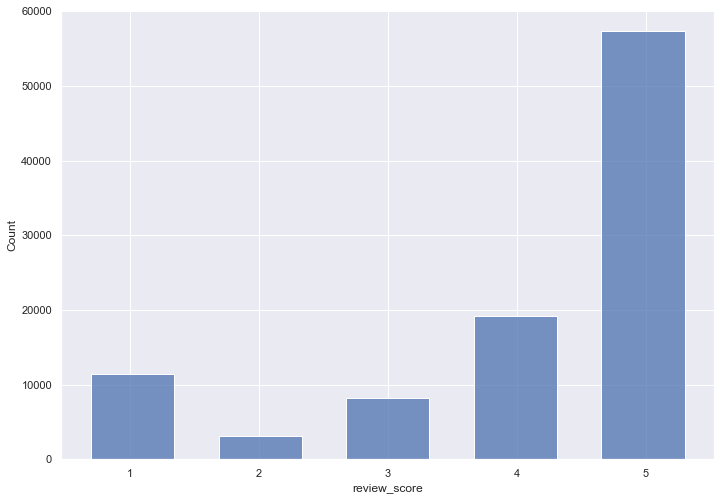

In [135]:
sns.histplot(reviews, x='review_score', shrink=15)

In [136]:
# join/merge tables
custo_reviews = matching_table[['customer_unique_id', 'order_id', 'review_id']]\
            .merge(reviews[['review_id', 'review_score', 'review_comment_message']], on = 'review_id', how='inner')
custo_reviews.head()

,customer_unique_id,order_id,review_id,review_score,review_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,a54f0611adc9ed256b57ede6b6eb5114,4,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente."
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,8d5266042046a06655c8db133d120ba5,4,Muito bom o produto.
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,e73b67b67587f7644d5bd1a52deb1b01,5,NaN
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,359d03e676b3c069f62cadba8dd3f6e8,5,O produto foi exatamente o que eu esperava e estava descrito no site e chegou bem antes da data prevista.
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,e50934924e227544ba8246aeb3770dd4,5,NaN


In [137]:
custo_reviews.shape

(115096, 5)

In [138]:
mean_review_score = custo_reviews.groupby(['customer_unique_id'])['review_score'].mean().reset_index()
mean_review_score.rename(columns={"review_score":"mean_review_score"}, inplace=True)
mean_review_score

,customer_unique_id,mean_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4.0
2,0000f46a3911fa3c0805444483337064,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,4.0
4,0004aac84e0df4da2b147fca70cf8255,5.0
...,...,...
95375,fffcf5a5ff07b0908bd4e2dbc735a684,5.0
95376,fffea47cd6d3cc0a88bd621562a9d061,4.0
95377,ffff371b4d645b6ecea244b27531430a,5.0
95378,ffff5962728ec6157033ef9805bacc48,5.0


In [139]:
# check result with customer having multiple orders/reviews => float ?
mean_review_score.loc[mean_review_score['customer_unique_id'] == '3e43e6105506432c953e165fb2acf44c']

,customer_unique_id,mean_review_score
23301,3e43e6105506432c953e165fb2acf44c,2.705882


In [140]:
mean_review_score['mean_review_score'].isna().sum()

0

In [141]:
# merge mean_review_score into
df_customers = df_customers.merge(mean_review_score[['customer_unique_id', 'mean_review_score']], on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,frequency,monetary,main_category,mean_review_score
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38,health_beauty,4.5
1,af07308b275d755c9edb36a90c618231,85,1,118.70,health_beauty,4.0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90,auto,5.0
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00,misc,5.0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90,books_stationery,5.0


In [142]:
# check nans
df_customers.loc[df_customers['mean_review_score'].isna()]

,customer_unique_id,recency,frequency,monetary,main_category,mean_review_score
154,528b011eb7fab3d59c336cc7248eed3a,280,1,53.99,health_beauty,NaN
310,ea870f4fdfd85ac98ab775b76efe3143,313,1,144.99,toys_gifts,NaN
381,367f4686d7112d69feed92b02a1775ed,516,2,130.00,furniture,NaN
389,c56d066e503008b8d0bf4204857c588d,112,1,69.00,toys_gifts,NaN
408,f329e0e1d8897ffa466a836ed216a23b,458,1,89.90,furniture,NaN
535,ec85abbbac44c1bb668a04903d033b6d,322,1,65.99,toys_gifts,NaN
829,dfe0f45b0b8cf0ce9c4cfb41c0808240,132,1,49.80,health_beauty,NaN
831,2990f218665832600f7180650703052d,587,1,159.90,books_stationery,NaN
1038,2e9cdecaa137e8ba2084bbde28c85105,323,1,597.90,toys_gifts,NaN
1124,d780d06a532da7d8d0435cd348e591fe,322,1,28.90,electronics,NaN


In [143]:
# other infos are interesting, inputing mean review score by category to complete

# matching each order main category and review score
product_review = matching_table[['customer_unique_id', 'product_id', 'review_id']]\
    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')\
    .merge(reviews[['review_id', 'review_score']])
product_review

,customer_unique_id,product_id,review_id,product_global_category,review_score
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,a54f0611adc9ed256b57ede6b6eb5114,home,4
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,b46f1e34512b0f4c74a72398b03ca788,home,4
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,dc90f19c2806f1abba9e72ad3c350073,home,5
3,e781fdcc107d13d865fc7698711cc572,87285b34884572647811a353c7ac498a,1bafb430e498b939f258b9c9dbdff9b1,home,3
4,af07308b275d755c9edb36a90c618231,595fac2a385ac33a80bd5114aec74eb8,8d5266042046a06655c8db133d120ba5,health_beauty,4
...,...,...,...,...,...
114254,fb9310710003399b031add3e55f34719,0df37da38a30a713453b03053d60d3f7,f5453b3d33358ed459eb4312392b96a8,sports_leisure,4
114255,fb9310710003399b031add3e55f34719,0df37da38a30a713453b03053d60d3f7,f5453b3d33358ed459eb4312392b96a8,sports_leisure,4
114256,a49e8e11e850592fe685ae3c64b40eca,3d2c44374ee42b3003a470f3e937a2ea,8ea780895f362ce949029f95b7181ff0,sports_leisure,1
114257,6359f309b166b0196dbf7ad2ac62bb5a,ac35486adb7b02598c182c2ff2e05254,e262b3f92d1ce917aa412a9406cf61a6,health_beauty,5


In [144]:
product_review['product_global_category'].isna().sum()

24

In [145]:
product_review['product_global_category'].fillna("unknown", inplace=True)

In [146]:
group_cat = product_review.groupby(by='product_global_category')

In [147]:
mean_review_category = product_review.groupby(by='product_global_category')['review_score'].mean()
mean_review_category

product_global_category
auto                4.064448
books_stationery    4.248680
construction        4.019728
electronics         3.956991
fashion             4.109934
furniture           3.860241
garden              4.040000
health_beauty       4.119538
home                4.055649
misc                4.175018
sports_leisure      4.090549
toys_gifts          4.093055
unknown             3.836275
Name: review_score, dtype: float64

In [148]:
# inputing to df_customers with missing review score : the overall mean review score by category
df_customers['mean_review_score'] = group_cat['review_score'].transform(lambda x: x.fillna(x.mean()))

In [149]:
df_customers

,customer_unique_id,recency,frequency,monetary,main_category,mean_review_score
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38,health_beauty,4
1,af07308b275d755c9edb36a90c618231,85,1,118.70,health_beauty,4
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90,auto,5
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00,misc,3
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90,books_stationery,4
...,...,...,...,...,...,...
95415,6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00,health_beauty,5
95416,da62f9e57a76d978d02ab5362c509660,253,1,174.90,health_beauty,5
95417,737520a9aad80b3fbbdad19b66b37b30,416,1,205.99,home,5
95418,5097a5312c8b157bb7be58ae360ef43c,282,1,359.98,electronics,1


In [150]:
# check nans
df_customers['mean_review_score'].isna().sum()

0

<AxesSubplot:xlabel='mean_review_score', ylabel='Count'>

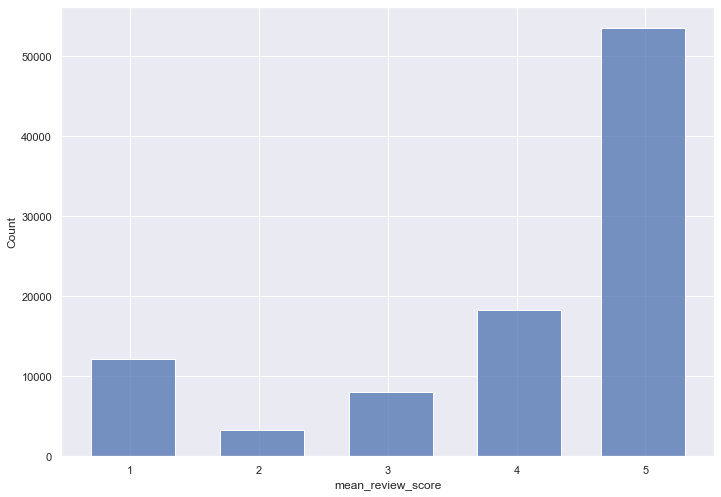

In [151]:
sns.histplot(df_customers, x='mean_review_score', shrink=15)

## percent written review made

In [152]:
custo_reviews['has_comment_message'] = custo_reviews['review_comment_message']
custo_reviews.head()

,customer_unique_id,order_id,review_id,review_score,review_comment_message,has_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,a54f0611adc9ed256b57ede6b6eb5114,4,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.","Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente."
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,8d5266042046a06655c8db133d120ba5,4,Muito bom o produto.,Muito bom o produto.
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,359d03e676b3c069f62cadba8dd3f6e8,5,O produto foi exatamente o que eu esperava e estava descrito no site e chegou bem antes da data prevista.,O produto foi exatamente o que eu esperava e estava descrito no site e chegou bem antes da data prevista.
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN


In [168]:
# count percent of na message per customer_unique_id
ratio_text_review = custo_reviews.groupby('customer_unique_id')['review_comment_message']\
                .apply(lambda x: x.notnull().sum()/len(x)*100).reset_index()

ratio_text_review.head()

,customer_unique_id,review_comment_message
0,0000366f3b9a7992bf8c76cfdf3221e2,100.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0
2,0000f46a3911fa3c0805444483337064,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,100.0
4,0004aac84e0df4da2b147fca70cf8255,0.0


In [169]:
ratio_text_review.shape

(95380, 2)

In [170]:
custo_reviews['customer_unique_id'].shape

(115096,)

In [171]:
df_customers = df_customers.merge(ratio_text_review, on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,frequency,monetary,main_category,mean_review_score,review_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38,health_beauty,4,100.0
1,af07308b275d755c9edb36a90c618231,85,1,118.70,health_beauty,4,100.0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90,auto,5,0.0
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00,misc,3,100.0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90,books_stationery,4,0.0


In [176]:
df_customers.shape

(95420, 7)

In [173]:
# check and handle NaN
df_customers.isna().sum()

customer_unique_id          0
recency                     0
frequency                   0
monetary                    0
main_category               0
mean_review_score           0
review_comment_message    699
dtype: int64

In [174]:
df_customers[df_customers['review_comment_message'].isna()]

,customer_unique_id,recency,frequency,monetary,main_category,mean_review_score,review_comment_message
154,528b011eb7fab3d59c336cc7248eed3a,280,1,53.99,health_beauty,5,NaN
310,ea870f4fdfd85ac98ab775b76efe3143,313,1,144.99,toys_gifts,3,NaN
381,367f4686d7112d69feed92b02a1775ed,516,2,130.00,furniture,4,NaN
389,c56d066e503008b8d0bf4204857c588d,112,1,69.00,toys_gifts,5,NaN
408,f329e0e1d8897ffa466a836ed216a23b,458,1,89.90,furniture,3,NaN
535,ec85abbbac44c1bb668a04903d033b6d,322,1,65.99,toys_gifts,5,NaN
829,dfe0f45b0b8cf0ce9c4cfb41c0808240,132,1,49.80,health_beauty,5,NaN
831,2990f218665832600f7180650703052d,587,1,159.90,books_stationery,1,NaN
1038,2e9cdecaa137e8ba2084bbde28c85105,323,1,597.90,toys_gifts,4,NaN
1124,d780d06a532da7d8d0435cd348e591fe,322,1,28.90,electronics,4,NaN


In [ ]:
# other infos for the concerned rows is valuable, 
# NaN here means that the concerned customer_unique_id weren't present in the reviews dataframe
# => insert value 0


In [177]:
df_customers['review_comment_message'].fillna(0, inplace=True)
df_customer

In [180]:
df_customers[df_customers['customer_unique_id'] == '528b011eb7fab3d59c336cc7248eed3a']

,customer_unique_id,recency,frequency,monetary,main_category,mean_review_score,review_comment_message
154,528b011eb7fab3d59c336cc7248eed3a,280,1,53.99,health_beauty,5,0.0


In [178]:
df_customers.shape

(95420, 7)

In [179]:
df_customers.isna().sum()

customer_unique_id        0
recency                   0
frequency                 0
monetary                  0
main_category             0
mean_review_score         0
review_comment_message    0
dtype: int64

# Retrait outliers méthode IQR

# distribution echantillon catégorie

In [1455]:
products[['product_id', 'product_global_category']]

,product_id,product_global_category
0,1e9e8ef04dbcff4541ed26657ea517e5,health_beauty
1,3aa071139cb16b67ca9e5dea641aaa2f,sports_leisure
2,96bd76ec8810374ed1b65e291975717f,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,health_beauty
4,9dc1a7de274444849c219cff195d0b71,home
...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,furniture
32947,bf4538d88321d0fd4412a93c974510e6,construction
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,furniture
32949,83808703fc0706a22e264b9d75f04a2e,electronics


In [1310]:
skewed_num_cols = ['frequency', 'recency']

In [1293]:
cat_list = df_customers['main_category'].unique().tolist()
cat_list

['health_beauty',
 'auto',
 'misc',
 'books_stationery',
 'unknown',
 'furniture',
 'garden',
 'electronics',
 'toys_gifts',
 'home',
 'sports_leisure',
 'construction',
 'fashion']

In [1507]:
num_cols = df_customers.columns[df_customers.dtypes.isin(['float64', 'int32', 'int64'])]
num_cols

Index(['recency', 'frequency'], dtype='object')

In [1297]:
df_customers.dtypes

customer_unique_id     object
recency                 int32
frequency               int64
monetary              float64
max_category           object
mean_review_score     float64
dtype: object

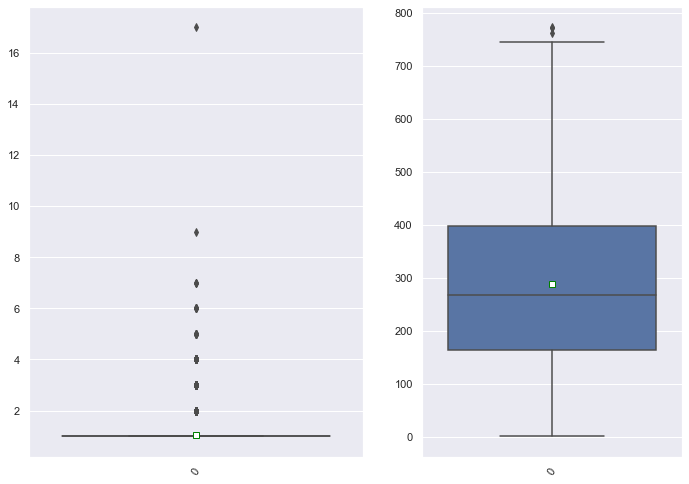

In [1311]:
MVA.boxplot_nums(df_customers, skewed_num_cols)

In [ ]:
ax = sns.histplot(df_customers['frequency'])

In [ ]:
ax = sns.histplot(df_customers['monetary'])

## Application IQR

In [1306]:
cat_list

['health_beauty',
 'auto',
 'misc',
 'books_stationery',
 'unknown',
 'furniture',
 'garden',
 'electronics',
 'toys_gifts',
 'home',
 'sports_leisure',
 'construction',
 'fashion']

In [1318]:
orders

,customer_id,order_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159
...,...,...
99436,39bd1228ee8140590ac3aca26f2dfe00,9c5dedf39a927c1b2549525ed64a053c
99437,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8
99438,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab
99439,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62


In [1316]:
q1 = df_customers.groupby(by='max_category')[skewed_num_cols].quantile(0.25)
q3 = df_customers.groupby(by='max_category')[skewed_num_cols].quantile(0.75)
iqr = q3 - q1

treshold = 1.5
out_low = q1 - treshold * iqr
out_high = q3 + treshold * iqr

In [ ]:
for pnn in pnns_list:
    pnn_df = df_no_outliers_cat.loc[sm_df['pnns_groups_1'] == pnn][skewed_num_cols]
    out_high_pnn = out_high.loc[out_high.index == pnn].squeeze()
    out_low_pnn = out_low.loc[out_low.index == pnn].squeeze()
    outliers = ((pnn_df > out_high_pnn) | (pnn_df < out_low_pnn)).any(axis=1)
    outliers_index = outliers[outliers == True].index
    
    df_no_outliers_cat.drop(index = outliers_index, inplace = True)

In [ ]:
MVA.boxplot_nums(df_customers, skewed_num_cols)

In [ ]:
ax = sns.histplot(df_customers['frequency'])

In [ ]:
ax = sns.histplot(df_customers['monetary'])

# Analyse uni-variée

In [1498]:
df_customers.shape

(95420, 6)

In [1499]:
df_customers.head()

,customer_unique_id,recency,frequency,monetary,main_category,mean_review_score
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38,health_beauty,4.0
1,af07308b275d755c9edb36a90c618231,85,1,118.70,health_beauty,4.0
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90,auto,5.0
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00,misc,3.0
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90,books_stationery,4.0


In [1500]:
df_customers.describe()

,recency,frequency,monetary,mean_review_score
count,95420.000000,95420.000000,95420.000000,95420.000000
mean,287.471851,1.034961,142.440198,4.024841
std,153.162334,0.214869,217.656355,1.389055
min,1.000000,1.000000,0.850000,1.000000
25%,163.000000,1.000000,47.900000,4.000000
50%,268.000000,1.000000,89.900000,5.000000
75%,397.000000,1.000000,155.000000,5.000000
max,773.000000,17.000000,13440.000000,5.000000


In [1501]:
df_customers.duplicated().sum()

0

In [1502]:
df_customers['customer_unique_id'].duplicated().sum()

0

In [1503]:
df_customers.isna().sum()

customer_unique_id    0
recency               0
frequency             0
monetary              0
main_category         0
mean_review_score     0
dtype: int64

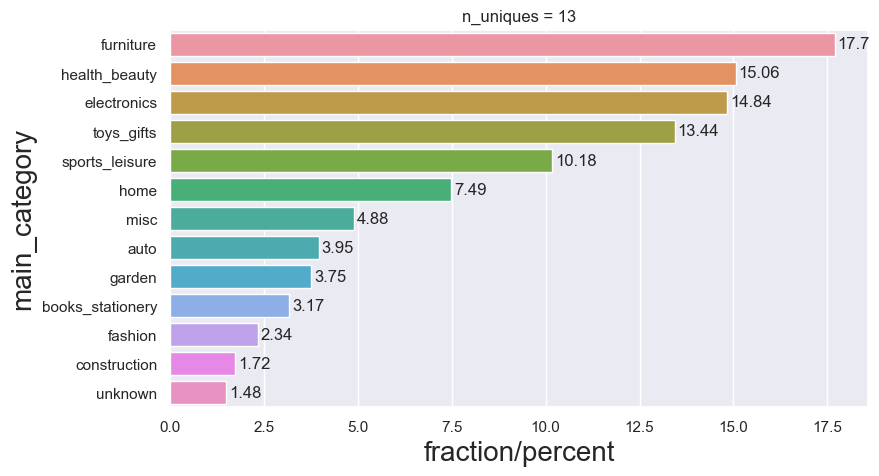

In [1504]:
UVA.category(df_customers, ['main_category'], 9, 5)

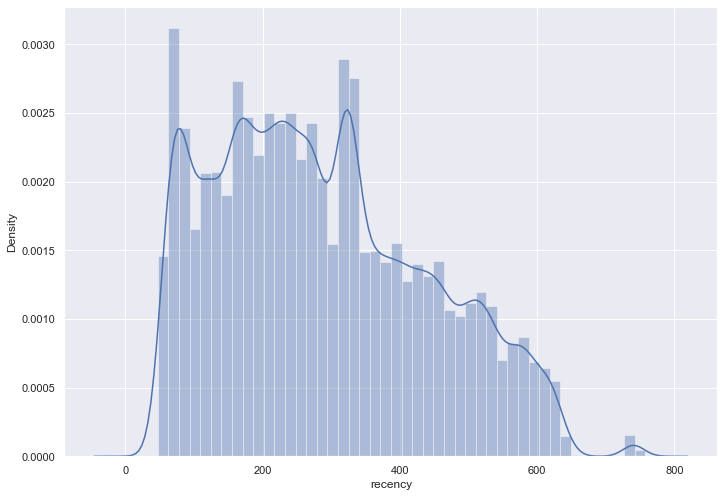

In [1307]:
# statistical distribution
ax = sns.distplot(df_customers['recency'])

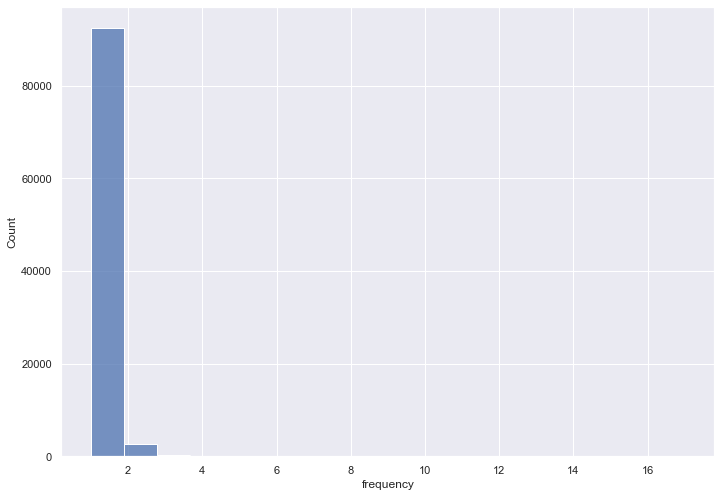

In [1314]:
ax = sns.histplot(df_customers['frequency'])

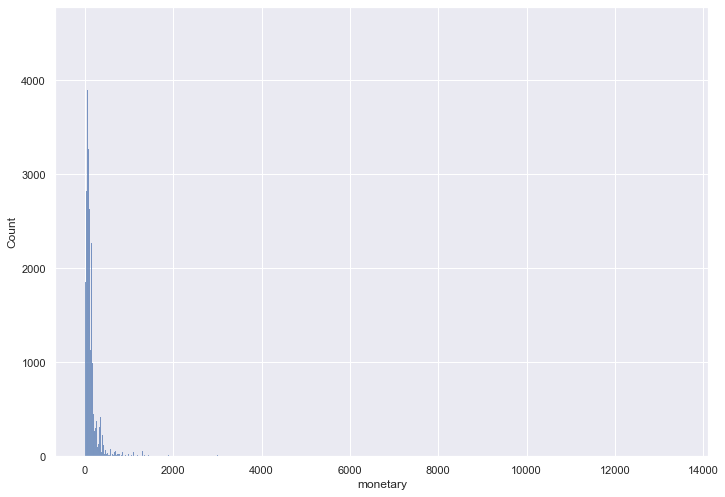

In [1309]:
ax = sns.histplot(df_customers['monetary'])

In [234]:
df_customers.dtypes

customer_unique_id     object
recency                 int32
frequency               int64
monetary              float64
dtype: object

In [273]:
num_cols = df_customers.select_dtypes(include=['int64','float64','Int64', 'int32'])[:]
num_cols.dtypes

recency        int32
frequency      int64
monetary     float64
dtype: object

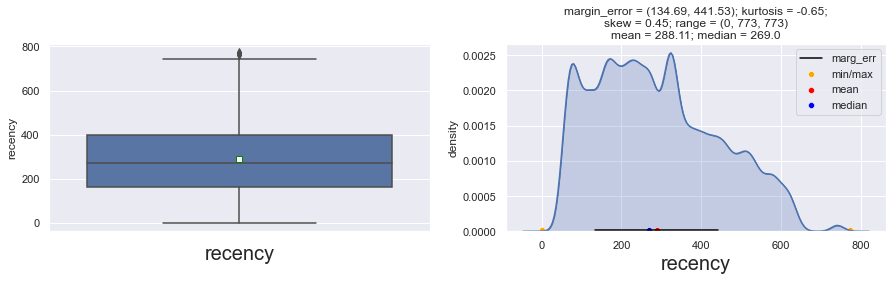

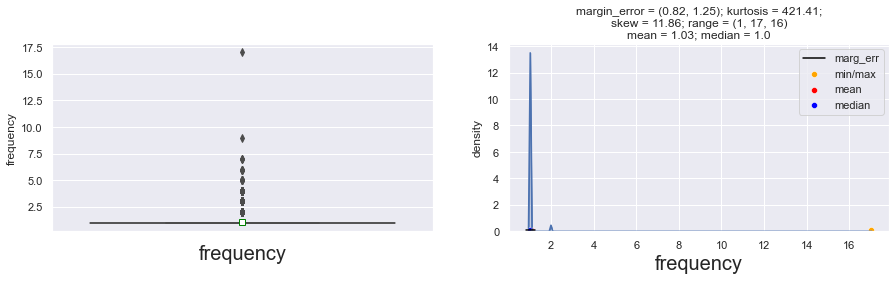

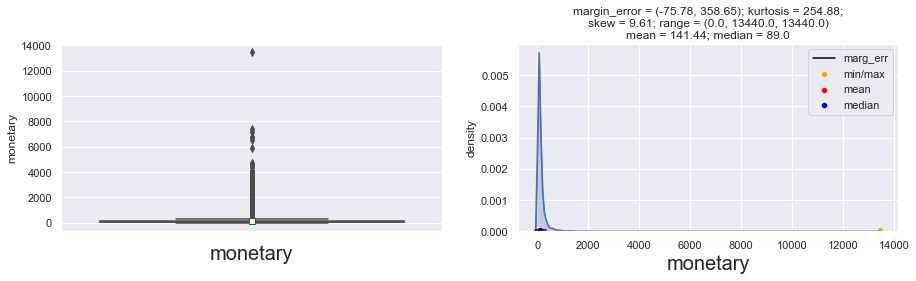

In [274]:
UVA.num_plus(df_customers, num_cols)

## Analyse bi-variée

In [237]:
df_customers.dtypes

customer_unique_id     object
recency                 int32
frequency               int64
monetary              float64
dtype: object

In [238]:
import utils.UVA as UVA
import utils.MVA as MVA

<Figure size 1755x1240.5 with 0 Axes>

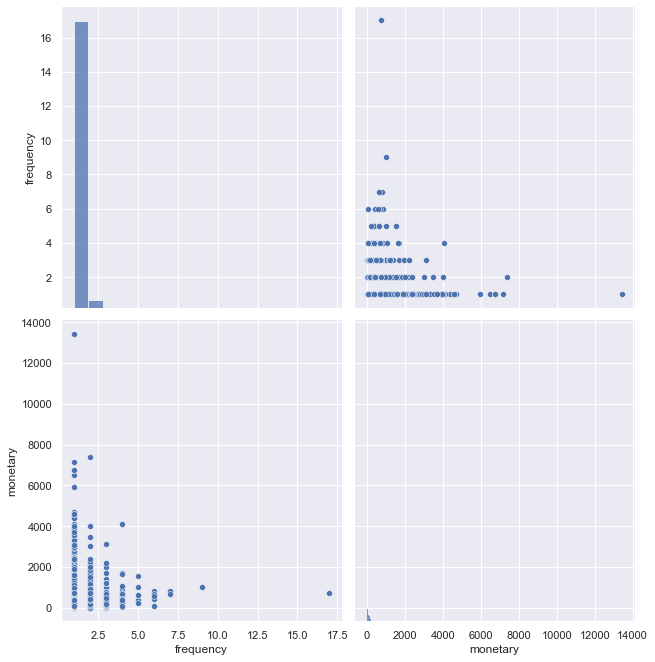

In [239]:
MVA.pairplot(df_customers)

In [240]:
#num_log.dtypes

## Multi-variée : Heatmap / matrice corrélation

In [241]:
# calculating correlation
num_cols = df_customers.select_dtypes(include=['int64','float64','Int64'])[:]

correlation = num_cols.dropna().corr()
correlation

,frequency,monetary
frequency,1.00000,0.10644
monetary,0.10644,1.00000


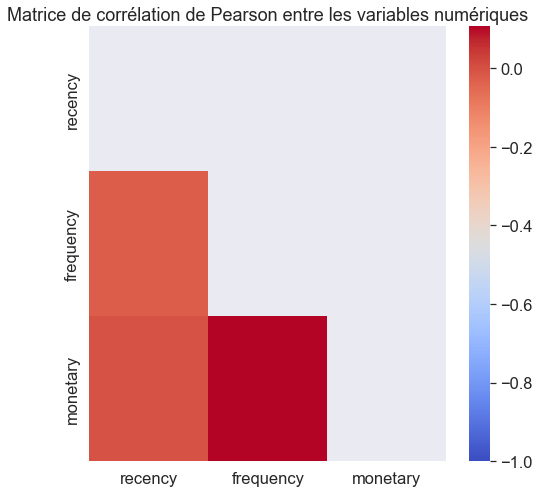

In [242]:
MVA.heatmap_num(df_customers
                #, annot=True
               ) ## annot true contrast

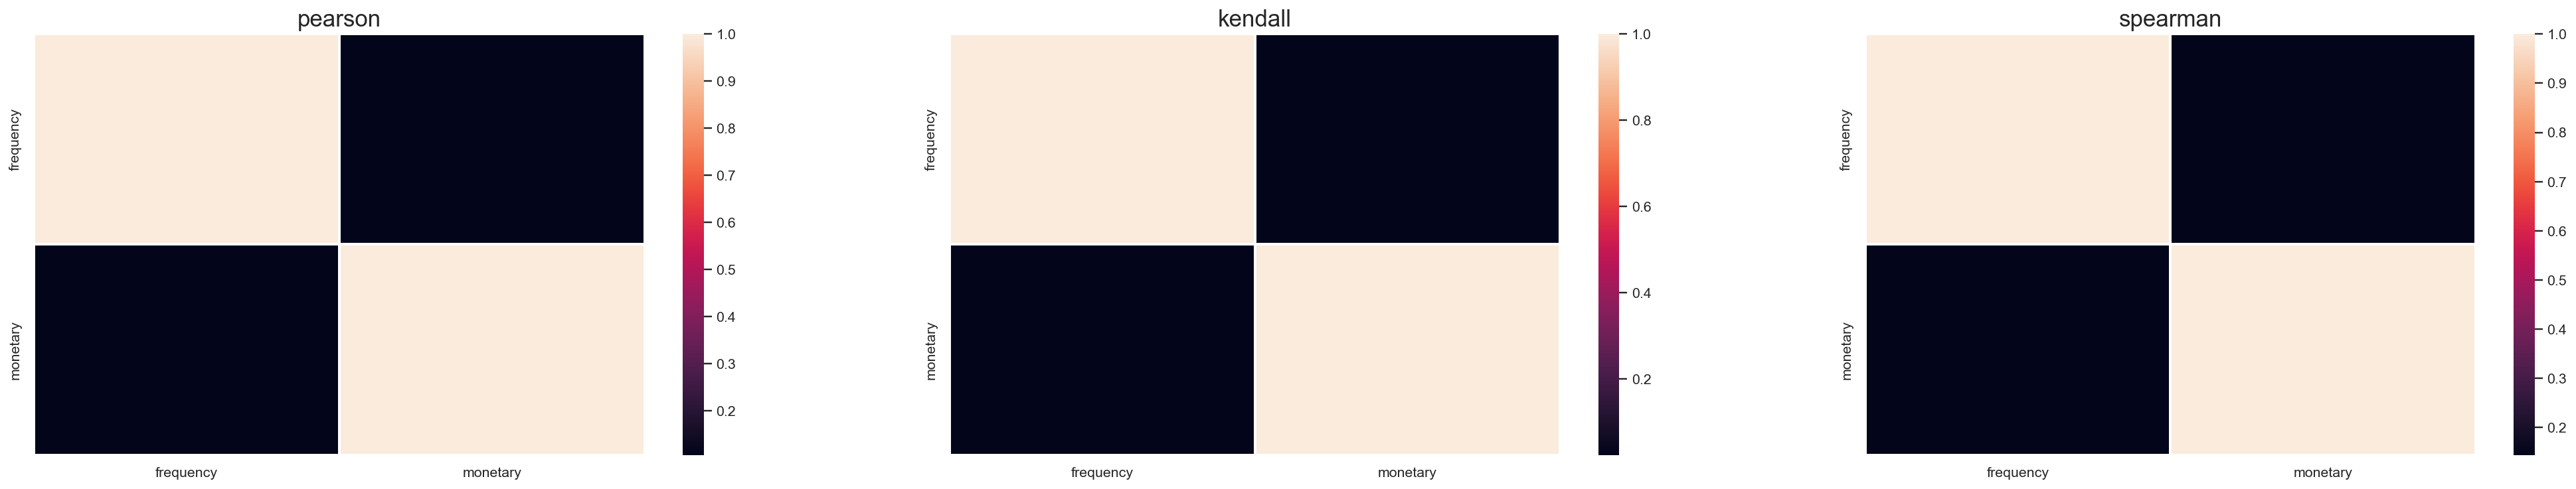

In [243]:
MVA.all_heatmaps(df_customers)

In [263]:
num_cols = df_customers.select_dtypes(include=['int64','float64','Int64', 'int32'])[:].columns.tolist()
num_cols

['recency', 'frequency', 'monetary']

In [264]:
df_customers.dtypes

customer_unique_id     object
recency                 int32
frequency               int64
monetary              float64
dtype: object

In [265]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

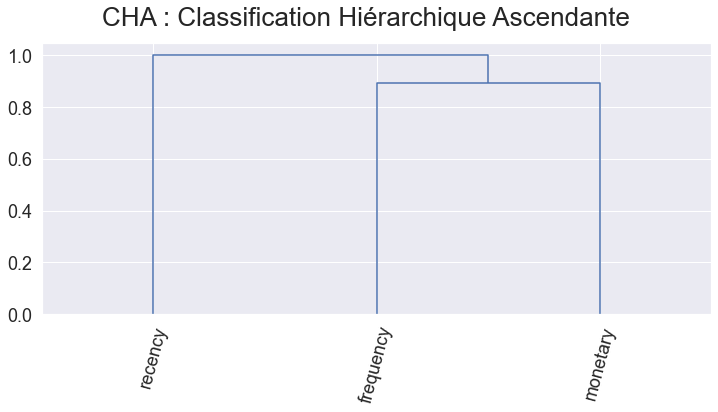

In [266]:
corr = df_customers[num_cols].corr()

plt.figure(figsize=(12,5))
dissimilarity = 1 - abs(corr)
Z = linkage(squareform(dissimilarity), 'complete')

dendrogram(Z, 
           labels=num_cols, 
           orientation='top', 
           leaf_rotation=75
          )
plt.suptitle('CHA : Classification Hiérarchique Ascendante', fontsize=26)
plt.tick_params(labelsize=18)

In [269]:
data

{'customers':                             customer_id                customer_unique_id  \
 0      06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
 1      18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
 2      4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
 3      b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
 4      4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
 ...                                 ...                               ...   
 99436  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
 99437  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
 99438  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
 99439  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
 99440  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   
 
        customer_zip_code_prefix          custome

In [271]:
data['order_items']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [ ]:
## method building : error check/catch : only process if elements are numerical values

In [ ]:
## todo : clustering sur RFM : kmeans / dbscan

In [ ]:
## essayer d'afficher avec ward